# VGG 19 Model

### Importing Libraries

In [56]:
import tensorflow as tf
from keras.preprocessing import image
from keras.preprocessing.image import ImageDataGenerator
from keras.layers import Input, Lambda, Dense, Flatten
from keras.models import Model
from keras.applications.vgg19 import VGG19
from keras.applications.vgg19 import preprocess_input
from keras.preprocessing import image
from glob import glob
import matplotlib.pyplot as plt


In [57]:
tf.__version__

'2.14.0'

### Data Preprocessing

In [58]:
import cv2
import numpy as np
from scipy.signal import convolve2d

def custom_preprocess_image(image_path):
    # Load the image in grayscale with error handling
    try:
        image = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
        
        # Check if the image was loaded successfully
        if image is None:
            raise Exception("Error loading the image.")
    
        # Ensure the input image is 8-bit (CV_8UC1)
        if image.dtype != np.uint8:
            image = np.uint8(image)

        # Apply imadjust (Contrast Stretching)
        min_val = np.min(image)
        max_val = np.max(image)
        adjusted_image = (image - min_val) / (max_val - min_val) * 255.0

        # Apply Weiner filter
        psf = np.ones((5, 5)) / 25  # Define a simple PSF (customizable)
        filtered_image = convolve2d(adjusted_image, psf, 'same')

        # Ensure the filtered image is 8-bit (CV_8UC1)
        if filtered_image.dtype != np.uint8:
            filtered_image = np.uint8(filtered_image)

        # Apply histogram equalization using CLAHE
        clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
        equalized_image = clahe.apply(filtered_image)

        # Resize the image to the desired dimensions (e.g., 224x224)
        image_size = (224, 224)
        resized_image = cv2.resize(equalized_image, image_size)
        
        if image is None:
            raise Exception("Error during preprocessing: Image became None.")

        # Expand the single-channel image to three channels (RGB format)
        rgb_image = cv2.cvtColor(resized_image, cv2.COLOR_GRAY2RGB)

        # Normalize pixel values to [0, 1]
        normalized_image = rgb_image / 255.0

        return normalized_image

    except Exception as e:
        print(f"Error preprocessing the image: {str(e)}")
        return None

### Visualising the processed image

In [59]:
#upload the image and apply the function
image_path = 'Dataset_2/test/PNEUMONIA/person20_virus_51.jpeg'
preprocessed_image = custom_preprocess_image(image_path)


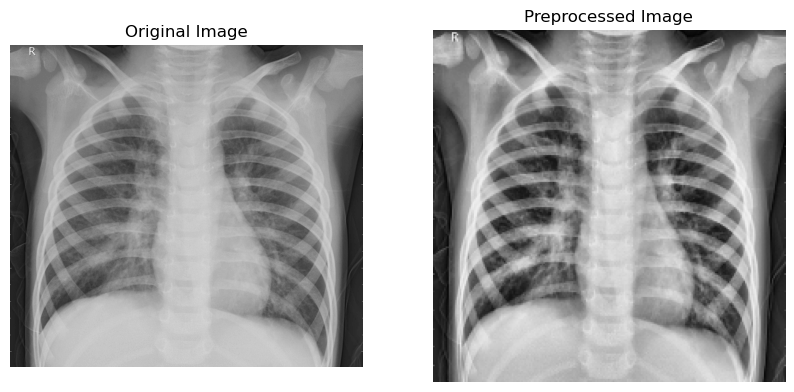

In [60]:
import matplotlib.pyplot as plt

def test_preprocessing(image_path):
    # Load the original image
    original_image = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)

    # Preprocess the image using the custom function
    preprocessed_image = custom_preprocess_image(image_path)

    # Create subplots to display the original and preprocessed images
    plt.figure(figsize=(10, 5))

    # Original Image
    plt.subplot(1, 2, 1)
    plt.imshow(original_image, cmap='gray')
    plt.title("Original Image")
    plt.axis('off')

    # Preprocessed Image
    plt.subplot(1, 2, 2)
    plt.imshow(preprocessed_image, cmap='gray')
    plt.title("Preprocessed Image")
    plt.axis('off')

    # Display the images
    plt.show()

# example:
test_preprocessing(image_path)


### Data Generators

In [61]:
# Creating an ImageDataGenerator with the custom preprocessing function
train_datagen = ImageDataGenerator(
    #preprocessing_function=custom_preprocess_image,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    horizontal_flip=True,
    rescale=1.0 / 255.0  # Normalize pixel values to [0, 1]
    
)

validation_datagen = ImageDataGenerator(
    #preprocessing_function=custom_preprocess_image,
    rescale=1.0 / 255.0
)

test_datagen = ImageDataGenerator(
    #preprocessing_function=custom_preprocess_image,
    rescale=1.0 / 255.0
)


In [62]:
# Define image dimensions and batch size
image_size = (224, 224)
batch_size = 32

In [63]:
training_set = train_datagen.flow_from_directory(
    'Dataset_2/train',
    target_size=image_size,
    batch_size=batch_size,
    class_mode='categorical' 
)

Found 5216 images belonging to 2 classes.


In [64]:
validation_set = validation_datagen.flow_from_directory(
    'Dataset_2/val',
    target_size=image_size,
    batch_size=batch_size,
    class_mode='categorical'
)

Found 29 images belonging to 2 classes.


In [65]:
test_set = test_datagen.flow_from_directory(
    'Dataset_2/test',
    target_size=image_size,
    batch_size=batch_size,
    class_mode='categorical'
)

Found 624 images belonging to 2 classes.


In [66]:
folders = glob('Dataset_2/train/*')
print(folders)

['Dataset_2/train\\NORMAL', 'Dataset_2/train\\PNEUMONIA']


## VGG 19 model

In [67]:
# Load the VGG-19 model with pre-trained weights (include_top=False for feature extraction)
vgg_model = VGG19(weights='imagenet', include_top=False, input_shape=(224, 224, 3))


In [68]:
# not training for existing weights
for layer in vgg_model.layers:
    layer.trainable = False

In [69]:
# our layers - 
from keras.layers import Dropout 
x = Flatten()(vgg_model.output)
x = Dense(256, activation='relu')(x) 
#x = Dense(256, activation='relu')(x) 
#x = Dropout(0.2)(x) 
x = Dense(128, activation='relu')(x) 

In [70]:
prediction = Dense(len(folders), activation='softmax')(x)

# create a model object
model = Model(inputs=vgg_model.input, outputs=prediction)
model.summary()

Model: "model_4"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_5 (InputLayer)        [(None, 224, 224, 3)]     0         
                                                                 
 block1_conv1 (Conv2D)       (None, 224, 224, 64)      1792      
                                                                 
 block1_conv2 (Conv2D)       (None, 224, 224, 64)      36928     
                                                                 
 block1_pool (MaxPooling2D)  (None, 112, 112, 64)      0         
                                                                 
 block2_conv1 (Conv2D)       (None, 112, 112, 128)     73856     
                                                                 
 block2_conv2 (Conv2D)       (None, 112, 112, 128)     147584    
                                                                 
 block2_pool (MaxPooling2D)  (None, 56, 56, 128)       0   

### Training the CNN

In [71]:
# Compiling the CNN

model.compile(
  loss='categorical_crossentropy',
  optimizer='adam',
  metrics=['accuracy']
)

In [72]:
r = model.fit(
  x=training_set,
  validation_data=test_set,
  epochs=5,
  steps_per_epoch=len(training_set),
  validation_steps=len(test_set)
)

Epoch 1/5
163/163 [==============================] - 3255s 20s/step - loss: 0.3386 - accuracy: 0.8888 - val_loss: 0.4641 - val_accuracy: 0.8253
Epoch 2/5
163/163 [==============================] - 3344s 21s/step - loss: 0.1650 - accuracy: 0.9321 - val_loss: 0.3340 - val_accuracy: 0.8894
Epoch 3/5
163/163 [==============================] - 3489s 21s/step - loss: 0.1518 - accuracy: 0.9411 - val_loss: 0.3735 - val_accuracy: 0.8830
Epoch 4/5
163/163 [==============================] - 3312s 20s/step - loss: 0.1474 - accuracy: 0.9438 - val_loss: 0.3055 - val_accuracy: 0.8910
Epoch 5/5
163/163 [==============================] - 2780s 17s/step - loss: 0.1372 - accuracy: 0.9429 - val_loss: 0.4111 - val_accuracy: 0.8750


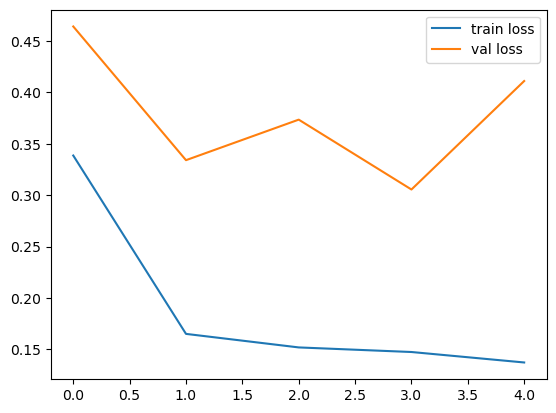

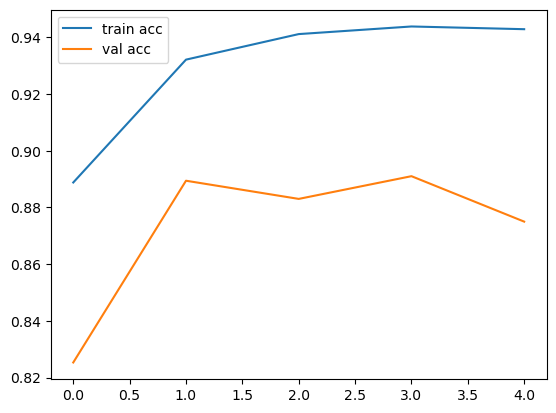

<Figure size 640x480 with 0 Axes>

In [73]:
# plot the loss
plt.plot(r.history['loss'], label='train loss')
plt.plot(r.history['val_loss'], label='val loss')
plt.legend()
plt.show()
plt.savefig('LossVal_loss')

# plot the accuracy
plt.plot(r.history["accuracy"], label='train acc')
plt.plot(r.history['val_accuracy'], label='val acc')
plt.legend()
plt.show()
plt.savefig('AccVal_acc')

In [74]:
# saving the model

import tensorflow as tf

from keras.models import load_model

model.save('model_vgg19_2.keras')

### Ensemble part

In [ ]:
from sklearn.ensemble import AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import numpy as np

# Combine the extracted features from all models
train_features_combined = np.concatenate([train_features_vgg16, train_features_vgg19, train_features_resnet50], axis=1)

num_samples = train_features_combined.shape[0]

# Convert one-hot encoded labels to 1D labels
train_labels_vgg16 = np.argmax(train_labels_vgg16, axis=1)

# Initialize a single AdaBoost classifier
ada_boost_classifier = AdaBoostClassifier(
    base_estimator=DecisionTreeClassifier(max_depth=10),  # You can adjust this parameter
    n_estimators=100,
    learning_rate=0.01  # You can adjust the number of estimators
)

# Fit the AdaBoost classifier using the combined features and labels
ada_boost_classifier.fit(train_features_combined, train_labels_vgg16[:num_samples])  # Ensure both feature and label arrays have the same number of samples
